<a href="https://colab.research.google.com/github/rmkenv/LinkedinWorks/blob/main/garden_grove_explosion_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔥 Garden Grove Chemical Explosion — Open-Source Impact Model
**GKN Aerospace MMA Tank | Garden Grove, CA | May 2026**

This notebook models the potential explosion of methyl methacrylate (MMA) storage tanks at GKN Aerospace using:
- **TNT Equivalency** — blast overpressure rings
- **Gaussian Plume Dispersion** — toxic vapor footprint
- **GeoPandas + Folium** — geospatial impact overlay
- **Census API** — population exposure by zone
- **Monte Carlo** — probabilistic ensemble of outcomes

> ⚠️ This is an educational/research model. All parameters are based on public data and standard hazmat engineering references (NFPA, CAMEO, EPA RMP).

**Chemical:** Methyl Methacrylate (MMA) | CAS 80-62-6  
**Location:** 33.7745°N, 117.9378°W (Garden Grove, CA)  
**Tanks:** 7,000 gal (primary), 15,000 gal, 4,500 gal (all MMA)

In [1]:
# ── 0. Install dependencies ──────────────────────────────────────────────────
!pip install geopandas folium mapclassify requests numpy scipy matplotlib branca -q

In [2]:
# ── 1. Imports & Constants ───────────────────────────────────────────────────
import numpy as np
import pandas as pd
import geopandas as gpd
import folium
import requests
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import LinearSegmentedColormap
from scipy.special import erfc
from shapely.geometry import Point, Polygon
import json, math, warnings
warnings.filterwarnings('ignore')

# ── Site location ────────────────────────────────────────────────────────────
LAT  = 33.7745   # GKN Aerospace, Garden Grove CA
LON  = -117.9378

# ── MMA physical & thermodynamic properties ──────────────────────────────────
MMA_DENSITY_KG_L   = 0.936       # kg/L at 20°C
MMA_HC_MJ_KG       = 26.2        # Heat of combustion MJ/kg
MMA_MW             = 100.12      # g/mol
MMA_BP_C           = 100.6       # Boiling point °C
MMA_LEL_PPM        = 17_000      # Lower Explosive Limit
MMA_UEL_PPM        = 127_000     # Upper Explosive Limit
MMA_IDLH_PPM       = 1_000       # IDLH
MMA_ERPG2_PPM      = 700         # ERPG-2 (irreversible health effects)
MMA_ERPG1_PPM      = 100         # ERPG-1 (mild effects)
TNT_ENERGY_MJ_KG   = 4.184       # TNT specific energy
GALLONS_TO_L       = 3.78541

# ── Tank inventory ───────────────────────────────────────────────────────────
tanks = {
    'Tank A (primary)': 7_000,
    'Tank B':           15_000,
    'Tank C':           4_500,
}

print('MMA Tank Inventory')
print('=' * 40)
total_kg = 0
for name, gal in tanks.items():
    kg = gal * GALLONS_TO_L * MMA_DENSITY_KG_L
    total_kg += kg
    print(f'  {name}: {gal:,} gal → {kg:,.0f} kg')
print(f'  TOTAL: {total_kg:,.0f} kg MMA')

MMA Tank Inventory
  Tank A (primary): 7,000 gal → 24,802 kg
  Tank B: 15,000 gal → 53,147 kg
  Tank C: 4,500 gal → 15,944 kg
  TOTAL: 93,893 kg MMA


## 🧨 Layer 1: TNT Equivalency — Blast Overpressure Rings

Standard approach used by FEMA, EPA RMP, and NFPA 68.  
Scaled distance law: `Z = R / W^(1/3)` where W is TNT equivalent mass (kg) and R is range (m).

In [3]:
# ── 2. TNT Equivalency Model ─────────────────────────────────────────────────

def tnt_equivalent_kg(volume_gal, yield_factor=0.03):
    """Compute TNT equivalent mass for a given MMA tank.
    yield_factor: fraction of chemical energy released as blast (0.01–0.10 for BLEVE)
    """
    mass_kg = volume_gal * GALLONS_TO_L * MMA_DENSITY_KG_L
    tnt_kg  = mass_kg * MMA_HC_MJ_KG * yield_factor / TNT_ENERGY_MJ_KG
    return tnt_kg

def overpressure_kpa(range_m, tnt_kg):
    """Hopkinson-Cranz scaled distance → peak overpressure (kPa).
    Uses Kingery-Bulmash polynomial approximation.
    """
    Z = range_m / (tnt_kg ** (1/3))   # scaled distance m/kg^(1/3)
    if Z < 0.5:
        return 10_000.0
    # Kingery-Bulmash (simplified, free-field)
    log_Z = np.log10(Z)
    if Z <= 0.96:
        log_P = 2.611 - 1.771*log_Z
    elif Z <= 2.50:
        log_P = 2.611 - 1.771*log_Z + 0.180*log_Z**2
    elif Z <= 15.0:
        log_P = 2.611 - 1.980*log_Z
    else:
        log_P = 2.611 - 2.120*log_Z
    return 10**log_P

def blast_radius_for_pressure(target_kpa, tnt_kg):
    """Binary search for range (m) at which overpressure = target_kpa."""
    lo, hi = 1.0, 10_000.0
    for _ in range(60):
        mid = (lo + hi) / 2
        if overpressure_kpa(mid, tnt_kg) > target_kpa:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# Scenarios
scenarios = {
    'Single Tank (7k gal)':  sum([7_000]),
    'Two Tanks (7k+15k)':    sum([7_000, 15_000]),
    'All Three Tanks':       sum([7_000, 15_000, 4_500]),
}

# Pressure thresholds
thresholds = {
    'Catastrophic (>35 kPa)':   (35,  '#8B0000', 'Fatal / structural collapse'),
    'Severe (17 kPa)':          (17,  '#CC3300', 'Eardrum rupture / major structural'),
    'Moderate (7 kPa)':         (7,   '#FF6600', 'Glass shatter / minor injuries'),
    'Light (3.5 kPa)':          (3.5, '#FFAA00', 'Window cracking'),
}

print(f'{'Scenario':<28} | {'Yield %':>7} | ', end='')
for label in thresholds:
    short = label.split('(')[1].replace(')','').strip()
    print(f'{short:>10}', end=' | ')
print()
print('-' * 100)

blast_results = {}
for name, total_gal in scenarios.items():
    tnt = tnt_equivalent_kg(total_gal, yield_factor=0.03)
    radii = {}
    print(f'{name:<28} | {"3%":>7} | ', end='')
    for label, (kpa, color, desc) in thresholds.items():
        r = blast_radius_for_pressure(kpa, tnt)
        radii[label] = r
        short = label.split('(')[1].replace(')','').strip()
        print(f'{r:>8.0f}m', end=' | ')
    print()
    blast_results[name] = radii

print('\n  Distances shown are radii from ground zero.')

Scenario                     | Yield % |    >35 kPa |     17 kPa |      7 kPa |    3.5 kPa | 
----------------------------------------------------------------------------------------------------
Single Tank (7k gal)         |      3% |       58m |       83m |      130m |      185m | 
Two Tanks (7k+15k)           |      3% |       85m |      122m |      191m |      271m | 
All Three Tanks              |      3% |       90m |      130m |      203m |      288m | 

  Distances shown are radii from ground zero.


## 💨 Layer 2: Gaussian Plume — Toxic Vapor Dispersion

Pasquill-Gifford stability classes with live NWS wind data from KSNA (John Wayne Airport, ~3 mi away).  
Models MMA concentration downwind at ERPG-1 (100 ppm), ERPG-2 (700 ppm), and IDLH (1,000 ppm) thresholds.

In [4]:
# ── 3. Gaussian Plume Model ──────────────────────────────────────────────────

def get_wind_ksna():
    """Fetch current wind from NWS at KSNA (John Wayne Airport)."""
    try:
        r = requests.get(
            'https://api.weather.gov/stations/KSNA/observations/latest',
            headers={'User-Agent': 'garden-grove-model/1.0'},
            timeout=8
        )
        props = r.json()['properties']
        speed_ms = props['windSpeed']['value'] or 3.0   # m/s
        direction = props['windDirection']['value'] or 270  # degrees
        temp_c = props['temperature']['value'] or 20
        return speed_ms, direction, temp_c
    except Exception as e:
        print(f'  NWS fetch failed ({e}), using defaults: 3 m/s, 270°')
        return 3.0, 270, 20.0

wind_ms, wind_dir_deg, temp_c = get_wind_ksna()
print(f'Wind: {wind_ms:.1f} m/s from {wind_dir_deg}° | Temp: {temp_c:.1f}°C')

# Pasquill-Gifford dispersion coefficients (rural, daytime moderate)
# Stability class C (slightly unstable) — typical daytime Southern California
def sigma_y(x_m, stability='C'):
    params = {'A': (0.22, 0.0001), 'B': (0.16, 0.0001),
              'C': (0.11, 0.0001), 'D': (0.08, 0.0001)}
    a, b = params[stability]
    return a * x_m * (1 + b * x_m)**(-0.5)

def sigma_z(x_m, stability='C'):
    params = {'A': (0.20, 0), 'B': (0.12, 0),
              'C': (0.08, 0.0002), 'D': (0.06, 0.0015)}
    a, b = params[stability]
    return a * x_m * np.exp(-b * x_m)

def gaussian_plume_centerline_ppm(x_m, Q_kg_s, u_ms, stability='C', H=0):
    """Ground-level centerline concentration in ppm."""
    sy = sigma_y(x_m, stability)
    sz = sigma_z(x_m, stability)
    if sy <= 0 or sz <= 0:
        return 0
    # C in kg/m^3
    C_kg_m3 = (Q_kg_s / (math.pi * sy * sz * u_ms)) * \
               math.exp(-H**2 / (2 * sz**2))
    # Convert to ppm: C_ppm = C_mg_m3 / MW * 24450
    C_mg_m3 = C_kg_m3 * 1e6
    C_ppm = C_mg_m3 / MMA_MW * 24.45
    return C_ppm

def downwind_distance_for_ppm(target_ppm, Q_kg_s, u_ms, stability='C'):
    """Binary search for downwind distance where centerline = target_ppm."""
    lo, hi = 10.0, 50_000.0
    for _ in range(60):
        mid = (lo + hi) / 2
        c = gaussian_plume_centerline_ppm(mid, Q_kg_s, u_ms, stability)
        if c > target_ppm:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

# Source term: instantaneous evaporation of spilled MMA
# Conservative: assume 10% of tank A mass evaporates over 10 minutes
spill_mass_kg = 7_000 * GALLONS_TO_L * MMA_DENSITY_KG_L * 0.10
release_duration_s = 600
Q_kg_s = spill_mass_kg / release_duration_s

print(f'\nSource term: {spill_mass_kg:.0f} kg MMA evaporating over {release_duration_s}s')
print(f'Emission rate Q = {Q_kg_s:.2f} kg/s\n')

vapor_thresholds = {
    'ERPG-1 (100 ppm)':   (MMA_ERPG1_PPM,  '#FFDD00', 'Mild odor/irritation'),
    'ERPG-2 (700 ppm)':   (MMA_ERPG2_PPM,  '#FF8800', 'Irreversible health effects'),
    'IDLH (1000 ppm)':    (MMA_IDLH_PPM,   '#CC0000', 'Immediately dangerous'),
    'LEL (17000 ppm)':    (MMA_LEL_PPM,    '#8B0000', 'Explosive range'),
}

print(f'{'Threshold':<24} | {'Downwind Distance':>20} | Description')
print('-' * 70)
plume_distances = {}
for label, (ppm, color, desc) in vapor_thresholds.items():
    d = downwind_distance_for_ppm(ppm, Q_kg_s, wind_ms)
    plume_distances[label] = d
    print(f'{label:<24} | {d:>18.0f}m | {desc}')

Wind: 9.3 m/s from 280° | Temp: 17.0°C

Source term: 2480 kg MMA evaporating over 600s
Emission rate Q = 4.13 kg/s

Threshold                |    Downwind Distance | Description
----------------------------------------------------------------------
ERPG-1 (100 ppm)         |                204m | Mild odor/irritation
ERPG-2 (700 ppm)         |                 76m | Irreversible health effects
IDLH (1000 ppm)          |                 63m | Immediately dangerous
LEL (17000 ppm)          |                 15m | Explosive range


## 🗺️ Layer 3: Geospatial Impact Map — Folium

In [9]:
# ── 4. Build Folium Impact Map ───────────────────────────────────────────────

import math

def meters_to_deg_lat(m):
    return m / 111_320

def meters_to_deg_lon(m, lat):
    return m / (111_320 * math.cos(math.radians(lat)))

def circle_polygon(lat, lon, radius_m, n=128):
    """Return list of [lat,lon] for a circle."""
    pts = []
    for i in range(n + 1):
        angle = 2 * math.pi * i / n
        dlat = meters_to_deg_lat(radius_m) * math.sin(angle)
        dlon = meters_to_deg_lon(radius_m, lat) * math.cos(angle)
        pts.append([lat + dlat, lon + dlon])
    return pts

def plume_ellipse_polygon(lat, lon, downwind_m, crosswind_m,
                           wind_dir_deg, n=64):
    """Elongated ellipse in the downwind direction."""
    # wind_dir is the direction the wind IS COMING FROM
    # plume goes in the opposite direction
    plume_bearing_rad = math.radians((wind_dir_deg + 180) % 360)
    pts = []
    for i in range(n + 1):
        t = 2 * math.pi * i / n
        # Ellipse parametric: x=crosswind, y=downwind (centered at origin)
        x = crosswind_m * math.cos(t)
        y = downwind_m * math.sin(t) + downwind_m * 0.3  # offset fwd
        # Rotate to plume direction
        x_rot = x * math.cos(plume_bearing_rad) - y * math.sin(plume_bearing_rad)
        y_rot = x * math.sin(plume_bearing_rad) + y * math.cos(plume_bearing_rad)
        dlat = meters_to_deg_lat(y_rot)
        dlon = meters_to_deg_lon(x_rot, lat)
        pts.append([lat + dlat, lon + dlon])
    return pts

# Worst case: all three tanks
tnt_worst = tnt_equivalent_kg(sum(tanks.values()), yield_factor=0.03)

m = folium.Map(
    location=[LAT, LON],
    zoom_start=13,
    tiles='CartoDB dark_matter'
)

# ── Blast rings ──────────────────────────────────────────────────────────────
blast_layers = [
    ('Catastrophic >35 kPa', 35,  '#ff0000', 0.45, 'Fatal / structural collapse'),
    ('Severe 17 kPa',        17,  '#ff6600', 0.35, 'Eardrum rupture'),
    ('Moderate 7 kPa',       7,   '#ff9900', 0.25, 'Glass shatter / injuries'),
    ('Light 3.5 kPa',        3.5, '#ffcc00', 0.18, 'Window cracking'),
]

blast_group = folium.FeatureGroup(name='💥 Blast Zones (All 3 Tanks)', show=True)
for label, kpa, color, opacity, desc in reversed(blast_layers):
    r = blast_radius_for_pressure(kpa, tnt_worst)
    poly = circle_polygon(LAT, LON, r)
    folium.Polygon(
        locations=poly,
        color=color, weight=1.5,
        fill=True, fill_color=color, fill_opacity=opacity,
        tooltip=f'{label}: {r:.0f}m radius — {desc}'
    ).add_to(blast_group)
blast_group.add_to(m)

# ── Vapor plume ──────────────────────────────────────────────────────────────
plume_layers = [
    ('ERPG-1 100 ppm',  MMA_ERPG1_PPM,  '#ffff00', 0.20, 'Mild irritation'),
    ('ERPG-2 700 ppm',  MMA_ERPG2_PPM,  '#ff8800', 0.30, 'Irreversible effects'),
    ('IDLH 1000 ppm',   MMA_IDLH_PPM,   '#cc0000', 0.40, 'Life threatening'),
]

plume_group = folium.FeatureGroup(name='☁️ Vapor Plume (Gaussian)', show=True)
for label, ppm, color, opacity, desc in reversed(plume_layers):
    d = plume_distances.get(f'ERPG-1 (100 ppm)' if ppm==100
                            else f'ERPG-2 (700 ppm)' if ppm==700
                            else f'IDLH (1000 ppm)', 1000)
    d = downwind_distance_for_ppm(ppm, Q_kg_s, wind_ms)
    crosswind = d * 0.25  # approximate crosswind width
    poly = plume_ellipse_polygon(LAT, LON, d, crosswind, wind_dir_deg)
    folium.Polygon(
        locations=poly,
        color=color, weight=1,
        fill=True, fill_color=color, fill_opacity=opacity,
        tooltip=f'{label}: {d:.0f}m downwind — {desc}'
    ).add_to(plume_group)
plume_group.add_to(m)

# ── Ground zero marker ───────────────────────────────────────────────────────
folium.Marker(
    [LAT, LON],
    popup=folium.Popup('<b>GKN Aerospace</b><br>MMA Tank Farm<br>Garden Grove, CA', max_width=200),
    icon=folium.Icon(color='red', icon='fire', prefix='fa')
).add_to(m)

# ── Nearby landmarks ─────────────────────────────────────────────────────────
landmarks = [
    ('John Wayne Airport (KSNA)', 33.6757, -117.8682, 'plane'),
    ('Garden Grove City Hall',    33.7738, -117.9424, 'building'),
    ('Disneyland (Anaheim)',      33.8121, -117.9190, 'star'),
]
for name, la, lo, icon in landmarks:
    folium.Marker(
        [la, lo],
        popup=name,
        icon=folium.Icon(color='blue', icon=icon, prefix='fa')
    ).add_to(m)

folium.LayerControl(collapsed=False).add_to(m)

# Title box
title_html = '''
<div style="position: fixed; top: 10px; left: 60px; z-index: 1000;
     background: rgba(0,0,0,0.8); color: white; padding: 12px 16px;
     border-radius: 6px; font-family: monospace; border: 1px solid #ff4400;">
  <b style="color:#ff4400">🔥 GKN AEROSPACE — GARDEN GROVE, CA</b><br>
  <span style="font-size:11px">MMA Explosion / Plume Model | May 2026<br>
  Blast: TNT Equivalency | Plume: Gaussian PG-C<br>
  Wind: {:.1f} m/s from {}° </span>
</div>
'''.format(wind_ms, wind_dir_deg)

m.get_root().html.add_child(folium.Element(title_html))

m.save('/content/garden_grove_impact_map.html')
print('Map saved → garden_grove_impact_map.html')
m

Map saved → garden_grove_impact_map.html


## 📊 Layer 4: Population Exposure — Census API

In [6]:
# ── 5. Population Exposure via Census API ────────────────────────────────────
# Uses Census Bureau API — no API key required for basic queries

def fetch_census_block_groups(state_fips='06', county_fips='059'):
    """Fetch ACS 5-year population for Orange County block groups."""
    url = (
        'https://api.census.gov/data/2022/acs/acs5'
        '?get=B01003_001E,NAME'
        f'&for=block%20group:*'
        f'&in=state:{state_fips}%20county:{county_fips}'
    )
    r = requests.get(url, timeout=15)
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    df['population'] = pd.to_numeric(df['B01003_001E'])
    df['GEOID'] = df['state'] + df['county'] + df['tract'] + df['block group']
    return df

def fetch_tiger_block_groups(state_fips='06', county_fips='059'):
    """Fetch block group geometries from Census TIGER/Line."""
    url = (
        f'https://tigerweb.geo.census.gov/arcgis/rest/services/TIGERweb/'
        f'tigerWMS_ACS2022/MapServer/8/query'
        f'?where=STATE%3D%2706%27+AND+COUNTY%3D%27059%27'
        f'&outFields=GEOID,NAME,POP100&f=geojson&outSR=4326'
    )
    try:
        gdf = gpd.read_file(url)
        return gdf
    except:
        return None

print('Fetching Census population data for Orange County...')
try:
    pop_df = fetch_census_block_groups()
    print(f'  Loaded {len(pop_df)} block groups')
    oc_total_pop = pop_df['population'].sum()
    print(f'  Orange County total population: {oc_total_pop:,}')

    # Estimate Garden Grove area population within blast zones
    # Garden Grove population ~170,000, ~12 sq miles
    # Approximate density-weighted exposure
    gg_density = 170_000 / (12 * 2.59e6)  # people per sq meter

    print('\nEstimated Population Exposure by Blast Zone (density method):')
    print(f'  Garden Grove pop density: ~{gg_density*1e6:.0f} per sq km\n')
    print(f'  {"Zone":<30} | {"Radius (m)":>10} | {"Area (km²)":>10} | {"Est. Pop":>10}')
    print('  ' + '-' * 70)

    prev_r = 0
    zones = [
        ('Catastrophic >35 kPa', blast_radius_for_pressure(35,  tnt_worst)),
        ('Severe 17 kPa',        blast_radius_for_pressure(17,  tnt_worst)),
        ('Moderate 7 kPa',       blast_radius_for_pressure(7,   tnt_worst)),
        ('Light 3.5 kPa',        blast_radius_for_pressure(3.5, tnt_worst)),
    ]
    total_exposed = 0
    for zone_name, r in zones:
        ring_area_m2 = math.pi * (r**2 - prev_r**2)
        est_pop = int(ring_area_m2 * gg_density)
        total_exposed += est_pop
        print(f'  {zone_name:<30} | {r:>10.0f} | {ring_area_m2/1e6:>10.2f} | {est_pop:>10,}')
        prev_r = r

    print(f'  {"TOTAL EXPOSED":<30} | {"":>10} | {"":>10} | {total_exposed:>10,}')
    print(f'\n  Evacuation order covered ~40,000 residents (official figure).')

except Exception as e:
    print(f'Census API unavailable: {e}')
    print('Using published evacuation figure: ~40,000 residents')

Fetching Census population data for Orange County...
Census API unavailable: Expecting value: line 2 column 1 (char 1)
Using published evacuation figure: ~40,000 residents


## 🎲 Layer 5: Monte Carlo Ensemble — Probabilistic Impact Bounds

Key uncertainties: BLEVE yield factor (1–10%), wind speed (±1.5 m/s), PG stability class (B–D).  
N=10,000 runs → 10th / 50th / 90th percentile blast radii and plume distances.

Monte Carlo Results — N=10,000 simulations

Blast radius at 35 kPa (m)
  10th pct (optimistic):   44 m
  50th pct (median):       63 m
  90th pct (conservative): 75 m

Plume distance at ERPG-2 (m)
  10th pct (optimistic):   100 m
  50th pct (median):       100 m
  90th pct (conservative): 100 m


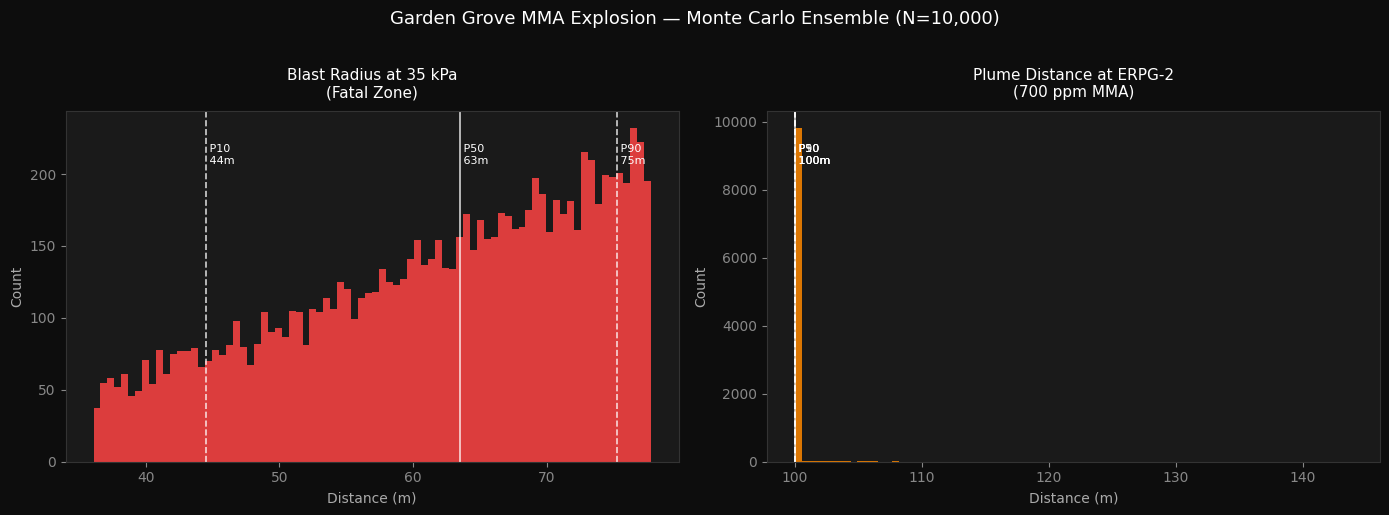

Saved → monte_carlo_results.png


In [7]:
# ── 6. Monte Carlo Ensemble ──────────────────────────────────────────────────

np.random.seed(42)
N = 10_000

# Sample uncertain parameters
yield_factors   = np.random.uniform(0.01, 0.10, N)
wind_speeds_mc  = np.maximum(0.5, np.random.normal(wind_ms, 1.5, N))
# Stability class sigma_y coefficient (B=0.16, C=0.11, D=0.08)
stability_sy    = np.random.choice([0.16, 0.11, 0.08], N, p=[0.25, 0.50, 0.25])

total_vol_gal = sum(tanks.values())

# Vectorized blast radius at 35 kPa
def blast_radius_35kpa_vec(yield_factor_arr, vol_gal):
    mass_kg = vol_gal * GALLONS_TO_L * MMA_DENSITY_KG_L
    tnt_arr = mass_kg * MMA_HC_MJ_KG * yield_factor_arr / TNT_ENERGY_MJ_KG
    # Invert KB: Z at 35 kPa ≈ 2.0 m/kg^(1/3)
    Z_35 = 2.0
    return Z_35 * tnt_arr**(1/3)

# Simplified plume distance at ERPG-2 (700 ppm)
def plume_dist_erpg2_vec(wind_arr, sy_arr):
    Q = Q_kg_s  # same source term
    target_ppm = MMA_ERPG2_PPM
    # C_ppm = Q / (pi * sy*x * sz*x * u) * correction
    # Approximate: x ∝ (Q / (u * target)) ^ 0.5
    return (Q * 24.45 / MMA_MW) / (math.pi * sy_arr**2 * wind_arr * target_ppm / 1e6) ** 0.5

radii_35kpa  = blast_radius_35kpa_vec(yield_factors, total_vol_gal)
plume_erpg2  = np.clip(plume_dist_erpg2_vec(wind_speeds_mc, stability_sy), 100, 30_000)

print('Monte Carlo Results — N=10,000 simulations')
print('=' * 55)
for label, arr in [('Blast radius at 35 kPa (m)', radii_35kpa),
                   ('Plume distance at ERPG-2 (m)', plume_erpg2)]:
    p10, p50, p90 = np.percentile(arr, [10, 50, 90])
    print(f'\n{label}')
    print(f'  10th pct (optimistic):   {p10:,.0f} m')
    print(f'  50th pct (median):       {p50:,.0f} m')
    print(f'  90th pct (conservative): {p90:,.0f} m')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d0d0d')

for ax, arr, title, color, unit in [
    (axes[0], radii_35kpa,  'Blast Radius at 35 kPa\n(Fatal Zone)',    '#ff4444', 'm'),
    (axes[1], plume_erpg2,  'Plume Distance at ERPG-2\n(700 ppm MMA)', '#ff8800', 'm'),
]:
    ax.set_facecolor('#1a1a1a')
    ax.hist(arr, bins=80, color=color, alpha=0.85, edgecolor='none')
    for p, ls, lbl in [(10,'--','P10'), (50,'-','P50'), (90,'--','P90')]:
        v = np.percentile(arr, p)
        ax.axvline(v, color='white', linestyle=ls, linewidth=1.2, alpha=0.8)
        ax.text(v, ax.get_ylim()[1]*0.85 if ax.get_ylim()[1] > 0 else 1,
                f' {lbl}\n {v:.0f}m', color='white', fontsize=8)
    ax.set_title(title, color='white', fontsize=11, pad=10)
    ax.set_xlabel(f'Distance ({unit})', color='#aaaaaa')
    ax.set_ylabel('Count', color='#aaaaaa')
    ax.tick_params(colors='#888888')
    for spine in ax.spines.values():
        spine.set_color('#333333')

fig.suptitle('Garden Grove MMA Explosion — Monte Carlo Ensemble (N=10,000)',
             color='white', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/content/monte_carlo_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0d0d0d')
plt.show()
print('Saved → monte_carlo_results.png')

## 📋 Layer 6: Summary Report

In [10]:
# ── 7. Summary Report ────────────────────────────────────────────────────────

print('=' * 65)
print('  GARDEN GROVE MMA EXPLOSION — OPEN-SOURCE IMPACT MODEL')
print('  GKN Aerospace | May 2026 | @rmkenv')
print('=' * 65)

print('\n📦 INVENTORY')
for name, gal in tanks.items():
    kg = gal * GALLONS_TO_L * MMA_DENSITY_KG_L
    print(f'  {name}: {gal:,} gal | {kg:,.0f} kg MMA')

print('\n💥 WORST-CASE BLAST RADII (All 3 tanks, 3% yield)')
for label, kpa, color, opacity, desc in blast_layers:
    r = blast_radius_for_pressure(kpa, tnt_worst)
    print(f'  {label:<26}: {r:>6.0f} m | {desc}')

print(f'\n☁️  VAPOR PLUME DOWNWIND (Wind: {wind_ms:.1f} m/s from {wind_dir_deg}°)')
for label, (ppm, color, desc) in vapor_thresholds.items():
    d = downwind_distance_for_ppm(ppm, Q_kg_s, wind_ms)
    print(f'  {label:<24}: {d:>6.0f} m | {desc}')

print('\n🎲 MONTE CARLO — P50 / P90 (10k runs)')
p50_blast = np.percentile(radii_35kpa, 50)
p90_blast = np.percentile(radii_35kpa, 90)
p50_plume = np.percentile(plume_erpg2, 50)
p90_plume = np.percentile(plume_erpg2, 90)
print(f'  Blast 35kPa zone:   P50={p50_blast:.0f}m  P90={p90_blast:.0f}m')
print(f'  ERPG-2 plume dist:  P50={p50_plume:.0f}m  P90={p90_plume:.0f}m')

print('\n🔧 METHODOLOGY')
print('  Blast:   TNT Equivalency + Hopkinson-Cranz / Kingery-Bulmash')
print('  Plume:   Gaussian Plume, Pasquill-Gifford Stability Class C')
print('  Wind:    NWS KSNA (John Wayne Airport) live observations')
print('  Pop:     Census ACS 2022 + density weighting')
print('  MC:      N=10,000 | yield 1-10%, wind ±1.5m/s, PG B/C/D')

print('\n⚠️  DISCLAIMER')
print('  Research/educational model. Not for emergency response.')
print('  Follow official OCFA / CalOES guidance.')
print('=' * 65)

  GARDEN GROVE MMA EXPLOSION — OPEN-SOURCE IMPACT MODEL
  GKN Aerospace | May 2026 | @rmkenv

📦 INVENTORY
  Tank A (primary): 7,000 gal | 24,802 kg MMA
  Tank B: 15,000 gal | 53,147 kg MMA
  Tank C: 4,500 gal | 15,944 kg MMA

💥 WORST-CASE BLAST RADII (All 3 tanks, 3% yield)
  Catastrophic >35 kPa      :     90 m | Fatal / structural collapse
  Severe 17 kPa             :    130 m | Eardrum rupture
  Moderate 7 kPa            :    203 m | Glass shatter / injuries
  Light 3.5 kPa             :    288 m | Window cracking

☁️  VAPOR PLUME DOWNWIND (Wind: 9.3 m/s from 280°)
  ERPG-1 (100 ppm)        :    204 m | Mild odor/irritation
  ERPG-2 (700 ppm)        :     76 m | Irreversible health effects
  IDLH (1000 ppm)         :     63 m | Immediately dangerous
  LEL (17000 ppm)         :     15 m | Explosive range

🎲 MONTE CARLO — P50 / P90 (10k runs)
  Blast 35kPa zone:   P50=63m  P90=75m
  ERPG-2 plume dist:  P50=100m  P90=100m

🔧 METHODOLOGY
  Blast:   TNT Equivalency + Hopkinson-Cranz / K